# Evaluasi Hasil OCR dengan CER & WER

Notebook ini menunjukkan cara **mengevaluasi kualitas hasil OCR** secara kuantitatif,
lalu memakainya untuk membandingkan dua kasus:

1. **OCR tanpa pra-pemrosesan** &mdash; citra langsung diberikan ke Tesseract apa adanya.
2. **OCR dengan pra-pemrosesan** &mdash; citra dibersihkan dulu (denoise, normalisasi
   iluminasi, perbesaran, binarisasi) sebelum diberikan ke Tesseract.

Dengan membandingkan skor error dari kedua kasus pada citra uji **yang persis sama**,
kita bisa melihat langsung seberapa besar efek pra-pemrosesan terhadap akurasi OCR.

## Metrik 1: Character Error Rate (CER)

CER mengukur proporsi karakter yang salah pada teks hasil OCR dibanding teks
acuan (*ground truth*), berdasarkan jarak edit (Levenshtein) antar karakter:

$$\text{CER} = \frac{S + D + I}{N}$$

di mana `S` = substitusi, `D` = penghapusan (*deletion*), `I` = penyisipan
(*insertion*), dan `N` = jumlah karakter pada teks acuan. Semakin **kecil**
CER, semakin baik hasil OCR-nya (0 = sempurna).

Contoh dari pustaka [`jiwer`](https://github.com/jitsi/jiwer):

```python
from jiwer import cer
error = cer("kucing", "kucinh")  # 0.1667
```

Satu huruf berbeda (`g` -> `h`) dari 6 karakter = 1/6 = 0.1667.

## Metrik 2: Word Error Rate (WER)

WER memakai rumus yang sama persis, hanya saja jarak edit dihitung per
**kata**, bukan per karakter:

$$\text{WER} = \frac{S_w + D_w + I_w}{N_w}$$

di mana `S_w`, `D_w`, `I_w` adalah substitusi/penghapusan/penyisipan **kata**,
dan `N_w` jumlah kata pada teks acuan.

```python
from jiwer import wer
error = wer("kucing itu lucu", "kucing itu lucuk")  # 0.3333
```

Satu kata berbeda (`lucu` -> `lucuk`) dari 3 kata = 1/3 = 0.3333.

**Kenapa dua-duanya dipakai?** CER lebih peka terhadap kesalahan kecil
(typo satu huruf), sedangkan WER mencerminkan dampaknya pada tingkat kata
&mdash; satu huruf salah pada OCR bisa saja membuat **seluruh kata** dianggap
salah oleh WER walau CER-nya kecil. Keduanya sering dilaporkan berdampingan
pada evaluasi OCR/ASR supaya gambarannya lebih lengkap.


In [1]:
# Instalasi dependensi (jalankan sekali saja)
# - jiwer            : hitung CER/WER
# - pytesseract      : wrapper Tesseract OCR
# - opencv-python-headless, pillow, numpy : olah & buat citra
#
# Tesseract sendiri adalah program terpisah (bukan paket pip), pasang lewat
# package manager sistem:
#   sudo apt install tesseract-ocr tesseract-ocr-ind
%pip install -q jiwer pytesseract opencv-python-headless pillow numpy matplotlib


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import pytesseract
from jiwer import cer, wer

# Contoh singkat cara kerja CER & WER (sesuai contoh di atas)
print("CER('kucing', 'kucinh')                          =", round(cer("kucing", "kucinh"), 4))
print("WER('kucing itu lucu', 'kucing itu lucuk')        =", round(wer("kucing itu lucu", "kucing itu lucuk"), 4))


CER('kucing', 'kucinh')                          = 0.1667
WER('kucing itu lucu', 'kucing itu lucuk')        = 0.3333


## 1. Menyiapkan citra uji

Karena repositori ini belum menyertakan berkas ijazah asli untuk diunggah,
citra uji dibuat secara **sintetis**: teks acuan (*ground truth*) dirender
menjadi gambar bersih, lalu "dirusak" agar menyerupai dokumen yang difoto
dengan HP seadanya &mdash; pencahayaan tidak merata, kertas pudar/fotokopi, dan
bintik noise. Pendekatan sintetis ini sama seperti yang dipakai pada
`deteksi_nomor_ijazah.py`/`deteksi_ttd.py` (lihat `panduanocr.md`) saat
belum ada sampel ijazah asli.

Karena teks acuan diketahui persis, CER bisa dihitung tanpa perlu
mengetik ulang transkripsi secara manual.


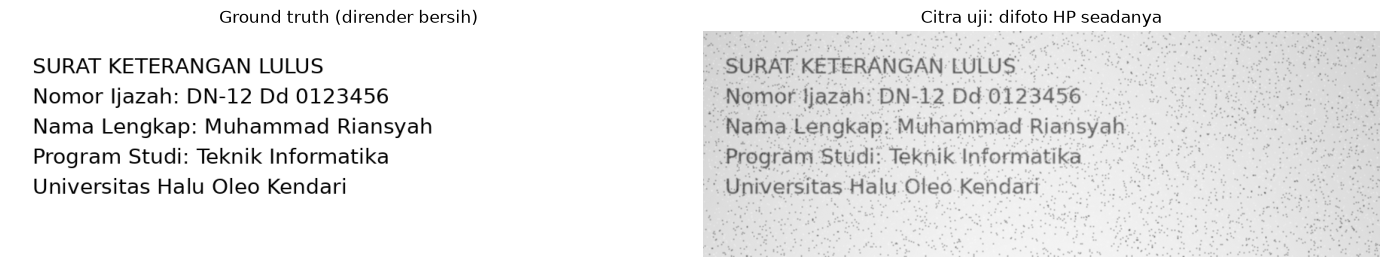

In [3]:
GROUND_TRUTH = (
    "SURAT KETERANGAN LULUS\n"
    "Nomor Ijazah: DN-12 Dd 0123456\n"
    "Nama Lengkap: Muhammad Riansyah\n"
    "Program Studi: Teknik Informatika\n"
    "Universitas Halu Oleo Kendari"
)


def buat_citra_bersih(teks, ukuran=(900, 300), font_size=28):
    """Render teks acuan menjadi citra grayscale bersih (simulasi dokumen asli)."""
    img = Image.new("L", ukuran, color=255)
    draw = ImageDraw.Draw(img)
    font = ImageFont.truetype(
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", font_size
    )
    draw.multiline_text((30, 30), teks, fill=0, font=font, spacing=14)
    return np.array(img)


def degradasi_scan_buruk(gray, seed=42):
    """Simulasikan dokumen difoto HP seadanya: kertas pudar, pencahayaan
    tidak merata, bintik noise garam-merica, dan sedikit blur."""
    rng = np.random.default_rng(seed)
    h, w = gray.shape

    # kertas pudar / fotokopi berulang -> kontras rendah, dasar jadi abu-abu
    img = cv2.convertScaleAbs(gray, alpha=0.55, beta=70).astype(np.float64)

    # pencahayaan tidak merata (foto HP, bukan scanner flatbed)
    yy, xx = np.mgrid[0:h, 0:w]
    img += 22 * np.sin(xx / w * np.pi) + 12 * (yy / h)

    # noise garam-merica (kotoran fotokopi & sensor kamera)
    mask = rng.random((h, w))
    img[mask < 0.015] = 0
    img[mask > 1 - 0.015] = 255

    # blur ringan (fokus kamera kurang tajam)
    img = cv2.GaussianBlur(np.clip(img, 0, 255).astype(np.uint8), (3, 3), 0.8)
    return img


citra_bersih = buat_citra_bersih(GROUND_TRUTH)
citra_buruk = degradasi_scan_buruk(citra_bersih)

fig, axs = plt.subplots(1, 2, figsize=(14, 4))
axs[0].imshow(citra_bersih, cmap="gray", vmin=0, vmax=255)
axs[0].set_title("Ground truth (dirender bersih)")
axs[0].axis("off")
axs[1].imshow(citra_buruk, cmap="gray", vmin=0, vmax=255)
axs[1].set_title("Citra uji: difoto HP seadanya")
axs[1].axis("off")
plt.tight_layout()
plt.show()


## 2. Kasus 1 &mdash; OCR **tanpa** pra-pemrosesan

Citra `citra_buruk` langsung diberikan ke Tesseract apa adanya.


In [4]:
def ocr(img, lang="ind"):
    return pytesseract.image_to_string(img, lang=lang, config="--psm 6").strip()


teks_tanpa_pra = ocr(citra_buruk)
cer_tanpa_pra = cer(GROUND_TRUTH, teks_tanpa_pra)
wer_tanpa_pra = wer(GROUND_TRUTH, teks_tanpa_pra)

print("Teks hasil OCR (tanpa pra-pemrosesan):")
print(teks_tanpa_pra)
print("-" * 60)
print(f"CER : {cer_tanpa_pra:.4f}")
print(f"WER : {wer_tanpa_pra:.4f}")


Teks hasil OCR (tanpa pra-pemrosesan):
5, SURAT KETERANGAN LULUS (0 Sana Kata Maan

Nomor'ijazah: DN-12 Dd-0123456 “ia da

“'Nama Lengkap: Muhammad Riansyah.' " “.. sana na 5
“Program Studi: Teknik Informatika... sa
' Universitas Halu Oleo Kendari DA peta San naa
------------------------------------------------------------
CER : 0.5235
WER : 1.5000


## 3. Kasus 2 &mdash; OCR **dengan** pra-pemrosesan

Sebelum di-OCR, citra yang sama dibersihkan dulu:

| # | Tahap | Tujuan |
|---|-------|--------|
| 1 | `medianBlur` | membuang bintik noise garam-merica tanpa mengaburkan tepi huruf |
| 2 | Normalisasi iluminasi (`morphologyEx` closing lalu dibagi) | meratakan pencahayaan yang tidak merata |
| 3 | Perbesar 2x (`resize`, `INTER_CUBIC`) | huruf jadi lebih tebal & mudah dikenali Tesseract |
| 4 | Binarisasi Otsu | memisahkan teks gelap dari latar terang secara tegas |

Urutan ini sejalan dengan pipeline pra-pemrosesan pada `preprocess.py` dan
`deteksi_nomor_ijazah.py` di folder ini.


In [5]:
def preprocess_untuk_ocr(gray):
    # 1. median blur: sangat efektif membuang noise garam-merica
    denoised = cv2.medianBlur(gray, 3)

    # 2. normalisasi iluminasi: perkirakan latar dgn closing lalu bagi citra dengannya
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (31, 31))
    latar = cv2.morphologyEx(denoised, cv2.MORPH_CLOSE, kernel)
    normal = cv2.divide(denoised, latar, scale=255)

    # 3. perbesar 2x agar huruf lebih tebal & mudah dibaca Tesseract
    besar = cv2.resize(normal, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)

    # 4. binarisasi otsu (teks gelap di latar terang)
    _, bw = cv2.threshold(besar, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return bw


citra_praproses = preprocess_untuk_ocr(citra_buruk)

teks_dengan_pra = ocr(citra_praproses)
cer_dengan_pra = cer(GROUND_TRUTH, teks_dengan_pra)
wer_dengan_pra = wer(GROUND_TRUTH, teks_dengan_pra)

print("Teks hasil OCR (dengan pra-pemrosesan):")
print(teks_dengan_pra)
print("-" * 60)
print(f"CER : {cer_dengan_pra:.4f}")
print(f"WER : {wer_dengan_pra:.4f}")


Teks hasil OCR (dengan pra-pemrosesan):
SURAT KETERANGAN LULUS . . Pa

Nomor Ijazah: DN-12 Dd 0123456 NN
' Nama Lengkap: Muhammad Riansyah

| Program Studi: Teknik Informatika Tg | .
Universitas Halu Oleo Kendari | : pi
------------------------------------------------------------
CER : 0.2013
WER : 1.1250


## 4. Perbandingan efek pra-pemrosesan (CER & WER)


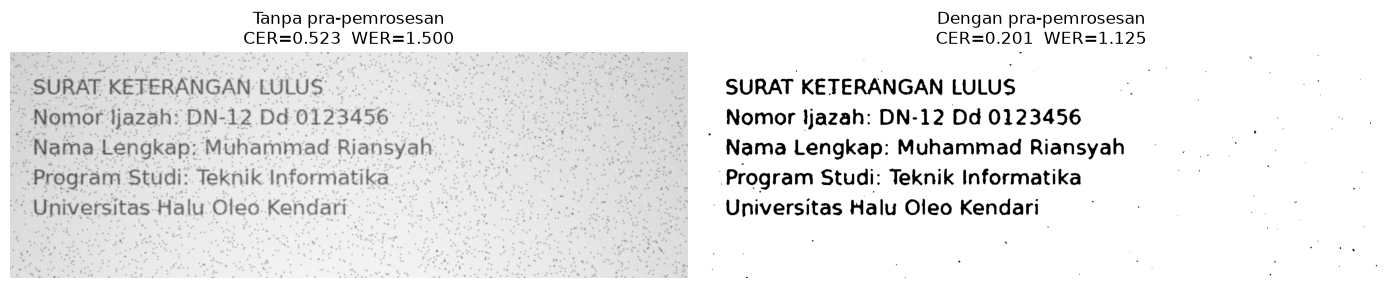

Kasus                              CER       WER
Tanpa pra-pemrosesan            0.5235    1.5000
Dengan pra-pemrosesan           0.2013    1.1250

Penurunan CER berkat pra-pemrosesan: 61.5%
Penurunan WER berkat pra-pemrosesan: 25.0%


In [6]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4))
axs[0].imshow(citra_buruk, cmap="gray", vmin=0, vmax=255)
axs[0].set_title(f"Tanpa pra-pemrosesan\nCER={cer_tanpa_pra:.3f}  WER={wer_tanpa_pra:.3f}")
axs[0].axis("off")
axs[1].imshow(citra_praproses, cmap="gray", vmin=0, vmax=255)
axs[1].set_title(f"Dengan pra-pemrosesan\nCER={cer_dengan_pra:.3f}  WER={wer_dengan_pra:.3f}")
axs[1].axis("off")
plt.tight_layout()
plt.show()

print(f"{'Kasus':<28}{'CER':>10}{'WER':>10}")
print(f"{'Tanpa pra-pemrosesan':<28}{cer_tanpa_pra:>10.4f}{wer_tanpa_pra:>10.4f}")
print(f"{'Dengan pra-pemrosesan':<28}{cer_dengan_pra:>10.4f}{wer_dengan_pra:>10.4f}")

turun_cer = (cer_tanpa_pra - cer_dengan_pra) / cer_tanpa_pra * 100 if cer_tanpa_pra else 0
turun_wer = (wer_tanpa_pra - wer_dengan_pra) / wer_tanpa_pra * 100 if wer_tanpa_pra else 0
print(f"\nPenurunan CER berkat pra-pemrosesan: {turun_cer:.1f}%")
print(f"Penurunan WER berkat pra-pemrosesan: {turun_wer:.1f}%")


## Kesimpulan

- **Tanpa pra-pemrosesan**, Tesseract langsung berhadapan dengan pencahayaan
  tidak merata, kontras rendah, dan bintik noise pada citra &mdash; CER **dan**
  WER-nya jauh lebih tinggi.
- **Dengan pra-pemrosesan** (denoise, normalisasi iluminasi, perbesaran,
  binarisasi Otsu), citra yang diberikan ke Tesseract jauh lebih bersih
  sehingga baik CER maupun WER turun signifikan.
- **CER vs WER**: perhatikan bahwa WER bisa turun lebih sedikit (secara
  relatif) dibanding CER. Ini wajar &mdash; satu huruf salah/tanda baca nyasar
  sudah cukup membuat WER menghitung satu kata penuh sebagai salah, padahal
  CER hanya menghitung selisih beberapa karakter saja. Karena itu kedua
  metrik sebaiknya dilaporkan bersamaan, tidak cukup salah satu saja.
- Angka CER/WER di atas bergantung pada citra uji (di sini disimulasikan).
  Pada data nyata (ijazah asli), jalankan alur yang sama: siapkan teks
  acuan (ketik manual atau dari data yang sudah diverifikasi), lalu bandingkan
  `cer(ground_truth, hasil_ocr)` dan `wer(ground_truth, hasil_ocr)` untuk
  tiap varian pra-pemrosesan yang ingin diuji.
- Pola ini bisa dipakai untuk menguji tahap pra-pemrosesan lain, misalnya
  `preprocess.py` (koreksi orientasi & *deskew*) pada berkas yang halamannya
  terbaring atau miring &mdash; bandingkan CER & WER sebelum & sesudah
  `siapkan_halaman()`.
